# Natural Language Processing Coursework

## Setup

In [1]:


import os
if not os.path.exists("NLPLabs-2024"):
    !git clone -q https://github.com/CRLala/NLPLabs-2024.git


if not os.path.exists("dontpatronizeme"):
    !git clone -q https://github.com/Perez-AlmendrosC/dontpatronizeme.git

    
pcl_tsv_path = "NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
train_split_path = "dontpatronizeme/semeval-2022/practice splits/train_semeval_parids-labels.csv"
dev_split_path   = "dontpatronizeme/semeval-2022/practice splits/dev_semeval_parids-labels.csv"


In [15]:
import os
from pathlib import Path
import re
import csv
import numpy as np
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2

In [7]:
rows=[]
with open(pcl_tsv_path) as f:
    for line in f.readlines()[4:]:
        par_id=line.strip().split('\t')[0]
        art_id = line.strip().split('\t')[1]
        keyword=line.strip().split('\t')[2]
        country=line.strip().split('\t')[3]
        t=line.strip().split('\t')[4]#.lower()
        l=line.strip().split('\t')[-1]
        if l=='0' or l=='1':
            lbin=0
        else:
            lbin=1
        rows.append(
            {'par_id':int(par_id),
            'doc_id':art_id,
            'keyword':keyword,
            'country':country,
            'text':t, 
            'label':lbin, 
            'orig_label':int(l)
            }
        )
df=pd.DataFrame(rows, columns=['par_id', 'doc_id', 'keyword', 'country', 'text', 'label', 'orig_label'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10469 entries, 0 to 10468
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   par_id      10469 non-null  int64
 1   doc_id      10469 non-null  str  
 2   keyword     10469 non-null  str  
 3   country     10469 non-null  str  
 4   text        10469 non-null  str  
 5   label       10469 non-null  int64
 6   orig_label  10469 non-null  int64
dtypes: int64(3), str(4)
memory usage: 3.4 MB


In [10]:
train_split = pd.read_csv(train_split_path)
dev_split   = pd.read_csv(dev_split_path)

train_ids = set(train_split.iloc[:, 0])
dev_ids   = set(dev_split.iloc[:, 0])

train_df = df[df["par_id"].isin(train_ids)].reset_index(drop=True)
dev_df   = df[df["par_id"].isin(dev_ids)].reset_index(drop=True)

print("All:", len(df), "Train:", len(train_df), "Dev:", len(dev_df))

All: 10469 Train: 8375 Dev: 2094


## 2. EDA

### 2.1. Basic Statistical Profiling

In [11]:
def class_table(df, name):
    n = len(df)
    pos = int((df["label"] == 1).sum())
    neg = int((df["label"] == 0).sum())
    pos_rate = pos / n if n else 0.0
    maj_acc = max(pos, neg) / n if n else 0.0
    return {
        "split": name,
        "n": n,
        "pos(PCL=1)": pos,
        "neg": neg,
        "pos_rate": pos_rate,
        "majority_acc": maj_acc,
    }

class_stats = pd.DataFrame([class_table(train_df, "train"), class_table(dev_df, "dev")])
class_stats

,split,n,pos(PCL=1),neg,pos_rate,majority_acc
0,train,8375,794,7581,0.094806,0.905194
1,dev,2094,199,1895,0.095033,0.904967


In [13]:
from huggingface_hub import login
import os
# Option 1: token from environment variable (recommended)
token = os.getenv("HF_TOKEN")
if token is not None:
    login(token=token)
else:
    # Interactive login (will prompt in notebook / terminal)
    login()

In [16]:
def normalize_ws(s):
    return re.sub(r"\s+", " ", s.strip())

train_df["text_norm"] = train_df["text"].astype(str).apply(normalize_ws)
dev_df["text_norm"]   = dev_df["text"].astype(str).apply(normalize_ws)

train_df["word_len"] = train_df["text_norm"].apply(lambda s: len(s.split()))
dev_df["word_len"]   = dev_df["text_norm"].apply(lambda s: len(s.split()))

tokenizer = AutoTokenizer.from_pretrained("roberta-base", use_fast=True)

def roberta_tok_len(s):
    return len(tokenizer(s, add_special_tokens=True, truncation=False)["input_ids"])

train_df["tok_len"] = train_df["text_norm"].apply(roberta_tok_len)
dev_df["tok_len"]   = dev_df["text_norm"].apply(roberta_tok_len)

def length_summary(df, col):
    qs = np.percentile(df[col], [50, 90, 95, 99, 99.5]).round(1)
    return pd.Series({
        "min": int(df[col].min()),
        "p50": qs[0],
        "p90": qs[1],
        "p95": qs[2],
        "p99": qs[3],
        "p99.5": qs[4],
        "max": int(df[col].max()),
        "mean": float(df[col].mean()),
    })

len_stats = pd.DataFrame({
    "train_word_len": length_summary(train_df, "word_len"),
    "train_tok_len":  length_summary(train_df, "tok_len"),
    "dev_tok_len":    length_summary(dev_df,   "tok_len"),
})
len_stats

Token indices sequence length is longer than the specified maximum sequence length for this model (546 > 512). Running this sequence through the model will result in indexing errors


,train_word_len,train_tok_len,dev_tok_len
min,1.000000,5.000000,2.000000
p50,42.000000,49.000000,48.000000
p90,84.000000,95.000000,92.000000
p95,102.000000,115.300000,112.000000
p99,142.000000,160.300000,158.000000
p99.5,156.000000,176.000000,176.100000
max,909.000000,1005.000000,355.000000
mean,48.675224,55.908657,54.538204


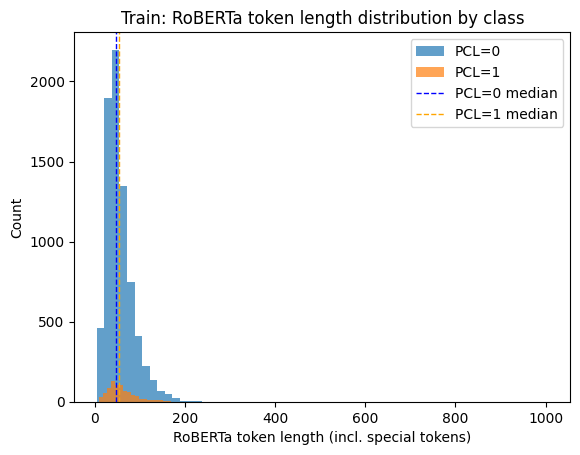

Train token length p99: 160.26000000000022
Suggested max_length bucket: 256


In [23]:
plt.figure()
plt.hist(train_df.loc[train_df["label"] == 0, "tok_len"], alpha=0.7, label="PCL=0", bins=60)
plt.hist(train_df.loc[train_df["label"] == 1, "tok_len"], alpha=0.7, label="PCL=1", bins=60)
plt.axvline(train_df.loc[train_df["label"] == 0, "tok_len"].median(), label="PCL=0 median", color="blue", linestyle="dashed", linewidth=1)
plt.axvline(train_df.loc[train_df["label"] == 1, "tok_len"].median(), label="PCL=1 median", color="orange", linestyle="dashed", linewidth=1)
plt.title("Train: RoBERTa token length distribution by class")
plt.xlabel("RoBERTa token length (incl. special tokens)")
plt.ylabel("Count")
plt.legend()
plt.show()

p99 = np.percentile(train_df["tok_len"], 99)
print("Train token length p99:", p99)

def suggest_max_length(p99):
    for L in [128, 256, 384, 512]:
        if p99 <= L:
            return L
    return 512

print("Suggested max_length bucket:", suggest_max_length(p99))

In [30]:
import numpy as np
import pandas as pd

def truncation_report(df, max_len, label_col="label", len_col="tok_len"):
    tmp = df[[label_col, len_col]].copy()
    tmp["truncated"] = tmp[len_col] > max_len
    tmp["overflow"] = (tmp[len_col] - max_len).clip(lower=0)

    overall = pd.Series({
        "max_len": max_len,
        "n": len(tmp),
        "trunc_rate": tmp["truncated"].mean(),
        "avg_overflow_given_trunc": tmp.loc[tmp["truncated"], "overflow"].mean() if tmp["truncated"].any() else 0.0,
        "p95_len": np.percentile(tmp[len_col], 95),
        "p99_len": np.percentile(tmp[len_col], 99),
        "max_len_observed": tmp[len_col].max(),
    })

    by_class = tmp.groupby(label_col).agg(
        n=(len_col, "size"),
        trunc_rate=("truncated", "mean"),
        avg_overflow_given_trunc=("overflow", lambda x: x[x > 0].mean() if (x > 0).any() else 0.0),
        p99_len=(len_col, lambda x: np.percentile(x, 99)),
        max_len_observed=(len_col, "max"),
    )
    return overall.to_frame("overall").T, by_class

for L in [128, 256, 384, 512]:
    overall, by_class = truncation_report(train_df, L)
    print("\n=== Train truncation report ===")
    print(overall)
    print(by_class)


=== Train truncation report ===
         max_len       n  trunc_rate  avg_overflow_given_trunc  p95_len  \
overall    128.0  8375.0    0.032358                 32.811808    115.3   

         p99_len  max_len_observed  
overall   160.26            1005.0  
          n  trunc_rate  avg_overflow_given_trunc  p99_len  max_len_observed
label                                                                       
0      7581    0.030867                 32.726496   161.00              1005
1       794    0.046599                 33.351351   155.21               546

=== Train truncation report ===
         max_len       n  trunc_rate  avg_overflow_given_trunc  p95_len  \
overall    256.0  8375.0    0.000836                215.142857    115.3   

         p99_len  max_len_observed  
overall   160.26            1005.0  
          n  trunc_rate  avg_overflow_given_trunc  p99_len  max_len_observed
label                                                                       
0      7581    0.00066

In [ ]:
import numpy as np
import pandas as pd
import scipy

# Assumes you have train_df with columns: y (0/1) and tok_len
def length_profile_by_class(df, max_len=256):
    tmp = df[["label", "tok_len"]].copy()
    tmp["truncated"] = tmp["tok_len"] > max_len
    tmp["overflow"]  = (tmp["tok_len"] - max_len).clip(lower=0)

    prof = tmp.groupby("label").agg(
        n=("tok_len", "size"),
        mean_tok_len=("tok_len", "mean"),
        median_tok_len=("tok_len", "median"),
        p90=("tok_len", lambda x: np.percentile(x, 90)),
        p95=("tok_len", lambda x: np.percentile(x, 95)),
        p99=("tok_len", lambda x: np.percentile(x, 99)),
        trunc_rate=("truncated", "mean"),
        avg_overflow_given_trunc=("overflow", lambda x: x[x > 0].mean() if (x > 0).any() else 0.0),
        max_tok_len=("tok_len", "max"),
    )
    prof.index = ["PCL=0", "PCL=1"]
    return prof

prof_256 = length_profile_by_class(train_df, max_len=256)
display(prof_256)

,n,mean_tok_len,median_tok_len,p90,p95,p99,trunc_rate,avg_overflow_given_trunc,max_tok_len
PCL=0,7581,55.440707,48.0,94.0,115.00,161.00,0.000660,240.8,1005
PCL=1,794,60.376574,53.0,101.7,126.35,155.21,0.002519,151.0,546


scipy not available; skipping Mann–Whitney test.


Lexical + leakage

In [ ]:
train_texts = set(train_df["text_norm"])
dev_texts   = set(dev_df["text_norm"])

overlap = len(train_texts & dev_texts)
print("Exact normalized text overlap train∩dev:", overlap)

train_dups = int(train_df["text_norm"].duplicated().sum())
dev_dups   = int(dev_df["text_norm"].duplicated().sum())
pd.DataFrame([{"split":"train", "within_split_duplicates": train_dups},
              {"split":"dev",   "within_split_duplicates": dev_dups}])

Exact normalized text overlap train∩dev: 0


,split,within_split_duplicates
0,train,0
1,dev,0


In [ ]:
artifact_patterns = {
    "has_url": r"(http://|https://|www\.)",
    "has_html_entity": r"(&\w+;|&#\d+;)",
    "has_weird_quotes": r'(""|“|”|‘|’)',
    "has_long_dash": r"(--|—)",
    "has_non_ascii": r"[^\x00-\x7F]",
}

def artifact_features(df):
    out = {}
    for name, pat in artifact_patterns.items():
        out[name] = df["text_norm"].str.contains(pat, regex=True).astype(int)
    return pd.DataFrame(out)

train_art = artifact_features(train_df)
train_art["label"] = train_df["label"].values

overall = train_art.drop(columns=["label"]).mean().to_frame("train_rate").T
by_class = train_art.groupby("label").mean()
by_class.index = [f"class_{i}" for i in by_class.index]
artifact_table = pd.concat([overall, by_class], axis=0)
artifact_table

C:\Users\Leon Kuessner\AppData\Local\Temp\ipykernel_29660\806054065.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out[name] = df["text_norm"].str.contains(pat, regex=True).astype(int)
C:\Users\Leon Kuessner\AppData\Local\Temp\ipykernel_29660\806054065.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out[name] = df["text_norm"].str.contains(pat, regex=True).astype(int)
C:\Users\Leon Kuessner\AppData\Local\Temp\ipykernel_29660\806054065.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out[name] = df["text_norm"].str.contains(pat, regex=True).astype(int)
C:\Users\Leon Kuessner\AppData\Local\Temp\ipykernel_29660\806054065.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match group

,has_url,has_html_entity,has_weird_quotes,has_long_dash,has_non_ascii
train_rate,0.000836,0.007761,0.250149,0.071403,0.0
class_0,0.000923,0.007783,0.241657,0.073077,0.0
class_1,0.000000,0.007557,0.331234,0.055416,0.0


In [40]:
X = train_df["text_norm"].values
y = train_df["label"].values

vec = CountVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)
Xv = vec.fit_transform(X)

chi2_scores, pvals = chi2(Xv, y)
feat_names = np.array(vec.get_feature_names_out())

# Top features most associated with PCL
top_k = 25
top_pos_idx = np.argsort(chi2_scores)[-top_k:][::-1]

top_pos = pd.DataFrame({
    "feature": feat_names[top_pos_idx],
    "chi2": chi2_scores[top_pos_idx],
    "p_value": pvals[top_pos_idx],
})

top_pos

,feature,chi2,p_value
0,hope,160.949032,7.019399e-37
1,christmas,156.511011,6.546384e-36
2,hungry,142.528893,7.451390e-33
3,our,121.955264,2.361021e-28
4,help,121.519635,2.940764e-28
5,children,116.420515,3.844839e-27
6,life,115.843530,5.143159e-27
7,lives,111.574949,4.427470e-26
8,god,105.333606,1.032108e-24
9,poor,101.431612,7.397376e-24


In [ ]:
import numpy as np
import pandas as pd

def keyword_slice_stats(df, min_count=50):
    g = df.groupby("keyword")["label"].agg(["count", "mean"]).rename(columns={"mean": "pos_rate"})
    g = g[g["count"] >= min_count].sort_values("pos_rate", ascending=False)
    return g

kw_train = keyword_slice_stats(train_df, min_count=50)
kw_dev   = keyword_slice_stats(dev_df,   min_count=20)

print("Top train keywords by positive rate (min_count=50):")
display(kw_train.head(15))

print("Top dev keywords by positive rate (min_count=20):")
display(kw_dev.head(15))

def js_divergence(p, q, eps=1e-12):
    p = p + eps
    q = q + eps
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return 0.5 * (kl_pm + kl_qm)

train_dist = train_df["keyword"].value_counts(normalize=True)
dev_dist   = dev_df["keyword"].value_counts(normalize=True)

all_kws = train_dist.index.union(dev_dist.index)
p = train_dist.reindex(all_kws, fill_value=0.0).values
q = dev_dist.reindex(all_kws, fill_value=0.0).values

print("JS divergence (train vs dev keyword distribution):", js_divergence(p, q))

Top train keywords by positive rate (min_count=50):


,count,pos_rate
keyword,,
homeless,865,0.172254
in-need,856,0.167056
poor-families,719,0.155772
hopeless,788,0.124365
refugee,880,0.082955
disabled,834,0.080336
vulnerable,871,0.068886
women,837,0.045400
migrant,882,0.035147


Top dev keywords by positive rate (min_count=20):


,count,pos_rate
keyword,,
poor-families,190,0.200000
in-need,226,0.146018
homeless,212,0.136792
hopeless,217,0.119816
vulnerable,209,0.095694
disabled,194,0.072165
refugee,188,0.069149
women,233,0.060086
immigrant,218,0.032110


JS divergence (train vs dev keyword distribution): 0.0007951205488867866


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_recall_curve, average_precision_score

kw_rate = train_df.groupby("keyword")["label"].mean()

global_prior = train_df["label"].mean()
dev_prob = dev_df["keyword"].map(kw_rate).fillna(global_prior).values

thresholds = np.linspace(0.0, 1.0, 501)
f1s = []
for t in thresholds:
    pred = (dev_prob >= t).astype(int)
    f1s.append(f1_score(dev_df["label"].values, pred, zero_division=0))

best_i = int(np.argmax(f1s))
best_t = float(thresholds[best_i])
best_f1 = float(f1s[best_i])

ap = float(average_precision_score(dev_df["label"].values, dev_prob))

print(f"Keyword-only baseline on dev:")
print(f"  global prior (train): {global_prior:.4f}")
print(f"  best threshold: {best_t:.3f}")
print(f"  best F1 (pos class): {best_f1:.4f}")
print(f"  AUPRC / AP: {ap:.4f}")

dev_tmp = dev_df.copy()
dev_tmp["prob_kw"] = dev_prob
dev_tmp["pred_kw"] = (dev_prob >= best_t).astype(int)
dev_tmp["err"] = (dev_tmp["pred_kw"] != dev_tmp["label"]).astype(int)

by_kw = dev_tmp.groupby("keyword").agg(
    n=("label","size"),
    pos_rate=("label","mean"),
    acc=("err", lambda x: 1 - x.mean()),
    fp=("pred_kw", lambda p: int(((p==1) & (dev_tmp.loc[p.index,"label"]==0)).sum())),
    fn=("pred_kw", lambda p: int(((p==0) & (dev_tmp.loc[p.index,"label"]==1)).sum())),
).sort_values("n", ascending=False)

display(by_kw.head(10))

Keyword-only baseline on dev:
  global prior (train): 0.0948
  best threshold: 0.126
  best F1 (pos class): 0.2418
  AUPRC / AP: 0.1368


,n,pos_rate,acc,fp,fn
keyword,,,,,
women,233,0.060086,0.939914,0,14
in-need,226,0.146018,0.146018,193,0
immigrant,218,0.032110,0.967890,0,7
hopeless,217,0.119816,0.880184,0,26
homeless,212,0.136792,0.136792,183,0
vulnerable,209,0.095694,0.904306,0,20
migrant,207,0.024155,0.975845,0,5
disabled,194,0.072165,0.927835,0,14
poor-families,190,0.200000,0.200000,152,0
